In [1]:
import sys
from pathlib import Path

current_dir = Path.cwd().resolve()
# walks upward until it finds a directory containing ppm/
PROJECT_ROOT = next(
    (p for p in (current_dir, *current_dir.parents) if (p / "ppm").is_dir()),
    current_dir,
)

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
from ppm.wandb_utils import load_multiple_experiments

plots_dir = PROJECT_ROOT / "plots/pre-training"
plots_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
PROJECTS=[
  "BPI12_001",
  "BPI12_002",
  "BPI12_003",
  "Distill_BPI12_001",
  "BPI15_001",
  "BPI15_002",
  "BPI15_003",
  "Distill_BPI15_001",
  "BPI17_001",
  "Distill_BPI17_001",
  "BPI17_002",
  "BPI17_003",
  "BPI19_001",
  "BPI19_002",
  "BPI19_003",
  "Distill_BPI19_001",  
  "BPI20_001",
  "BPI20_002",
  "BPI20_003",
  "Distill_BPI20_PTC_001",
  "Distill_BPI20_RFP_001",
  "Distill_BPI20_TPD_001",
  "Distill_BPI20_PTC_002",
  "Distill_BPI20_RFP_002",
  "Distill_BPI20_TPD_002",
  "LSTM_001",
  "baseline-nep"
]

runs_raw, _ = load_multiple_experiments(PROJECTS, force_update=False)

runs_raw["best_test_final_next_activity_f1"] = (
    runs_raw["best_test_final_next_activity_f1"]
    .combine_first(runs_raw["best_test_final_next_activity_f1_macro"])
)
#runs_raw = runs_raw.drop(columns=["best_test_final_next_activity_f1_macro"])



Database already exists: /app/visualization/paper/metrics/BPI12_001.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/paper/metrics/BPI12_002.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/paper/metrics/BPI12_003.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/paper/metrics/Distill_BPI12_001.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/paper/metrics/BPI15_001.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/paper/metrics/BPI15_002.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/paper/metrics/BPI15_003.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/paper/metrics/Distill_BPI15_001.db
Use force_update=True to re-fetch from wandb
Database already exists: /app/visualization/paper/metric

In [50]:
import pandas as pd

pd.set_option("display.max_columns", None)   # show all columns
pd.set_option("display.width", None)         # don't wrap/truncate by width
pd.set_option("display.max_colwidth", None)  # optional: full cell content

runs_raw.columns

Index(['id', 'name', 'r', 'lr', 'log', 'device', 'epochs', 'compile',
       'n_heads', 'backbone',
       ...
       'train_next_activity_CE_loss', 'train_next_activity_KL_loss',
       'train_next_activity_total_loss', 'val_next_activity_CE_loss',
       'val_next_activity_KL_loss', 'val_next_activity_total_loss', 'seed',
       'prediction_table', 'transition_table',
       'best_test_final_next_activity_f1_macro'],
      dtype='str', length=118)

In [65]:
# prepocessing
runs = runs_raw.copy()

EXCLUDE = ["LSTM-256-1", "LSTM-128-1"]

fine_tuning_col = "fine_tuning" if "fine_tuning" in runs.columns else "fine-tuning"
freeze_layers_col = "freeze_layers" if "freeze_layers" in runs.columns else "freeze-layers"
mask_no_finetuning = runs[fine_tuning_col].isna() | (runs[fine_tuning_col].astype(str) == "None")
runs.loc[mask_no_finetuning, freeze_layers_col] = "all"

for col in ["hidden_size", "n_layers", "n_heads"]:
    if col in runs.columns:
        runs[col] = pd.to_numeric(runs[col], errors="coerce")

def _fmt_int(v):
    return str(int(v)) if pd.notna(v) else "nan"

def _arch_label(df: pd.DataFrame) -> pd.Series:
    hs = df["hidden_size"].map(_fmt_int).astype("string")
    nl = df["n_layers"].map(_fmt_int).astype("string")
    nh = df["n_heads"].map(_fmt_int).astype("string")
    return hs.str.cat([nl, nh], sep="-")

def _lstm_label(df: pd.DataFrame) -> pd.Series:
    hs = df["hidden_size"].map(_fmt_int).astype("string")
    nl = df["n_layers"].map(_fmt_int).astype("string")
    return hs.str.cat(nl, sep="-")

# Identify distill and scratch (nano) runs separately
lstm_mask = runs["project"].astype(str).str.startswith("LSTM_00", na=False)
distill_mask = runs["project"].astype(str).str.startswith("Distill", na=False)
scratch_mask = (
    runs["backbone"].astype(str).str.contains("student", na=False)
    & ~distill_mask
)

runs.loc[lstm_mask, "backbone"] = "LSTM-" + _lstm_label(runs.loc[lstm_mask])
runs.loc[scratch_mask, "backbone"] = "nano-" + _arch_label(runs.loc[scratch_mask])
runs.loc[distill_mask, "backbone"] = "distill-" + _arch_label(runs.loc[distill_mask])

backbone_rename_map = {
    "BPI20PrepaidTravelCosts": "BPI20_PTC",
    "BPI20TravelPermitData": "BPI20_TPD",
    "BPI20RequestForPayment": "BPI20_RfP",
}
runs["log"] = runs["log"].replace(backbone_rename_map)
runs = runs[~runs["backbone"].isin(EXCLUDE)].copy()


## Show data

In [66]:
METRIC = "best_test_final_next_activity_acc"
#METRIC = "best_test_final_next_activity_f1"

MODELS = "all" # [["gpt2-mini", "nano_512_4_8"], ["gpt2-small", "nano_768_12_12"]]

for col in ["categorical_features", "continuous_features"]:
    if col in runs.columns:
        runs[col] = runs[col].astype(str)

GROUP_COLS = ["log", "backbone", "freeze_layers", "lr", "batch_size", "categorical_features", "continuous_features"]

EXTRA_COLS = ["project", "total_params", "trainable_params", "embedding_size"]
EXTRA_COLS = [c for c in EXTRA_COLS if c in runs.columns]  # only keep ones that exist

# Build df with everything we need
df = runs[GROUP_COLS + ["id", METRIC] + EXTRA_COLS].dropna(subset=[METRIC]).copy()
df[METRIC] = df[METRIC].astype(float)

# only retain relevant models
if not MODELS == "all":
    df = df[df["backbone"].isin([m for group in MODELS for m in group])]

# 1) Metric stats (ONLY from METRIC)
agg = (
    df.groupby(GROUP_COLS, dropna=False)[METRIC]
      .agg(["count", "mean", "std", "min", "max"])
      .rename(columns={
          "count": "n_runs",
          "mean": "acc_mean",
          "std": "acc_std",
          "min": "acc_min",
          "max": "acc_max",
      })
)

# 2) Add “descriptor” columns (not metric-related)
#    We assume these are constant within group; if not, we’ll detect it below.
descriptors = df.groupby(GROUP_COLS, dropna=False)[EXTRA_COLS].first() if EXTRA_COLS else None

# Optional: detect groups where descriptors are NOT constant
if EXTRA_COLS:
    nunique = df.groupby(GROUP_COLS, dropna=False)[EXTRA_COLS].nunique(dropna=False)
    bad = (nunique > 1).any(axis=1)
    if bad.any():
        print("Warning: some groups have varying descriptor values:")
        display(nunique[bad].reset_index())

# 3) Best run id per group (based on METRIC)
best_idx = df.groupby(GROUP_COLS, dropna=False)[METRIC].idxmax()
best_runs = df.loc[best_idx].set_index(GROUP_COLS)["id"].rename("best_run_id")

# 4) Combine
summary = agg
if descriptors is not None:
    summary = summary.join(descriptors)

summary = summary.join(best_runs).reset_index()
summary["n_runs"] = summary["n_runs"].astype(int)

for col in ["acc_mean", "acc_std", "acc_min", "acc_max"]:
    summary[col] = summary[col].map(lambda x: f"{x:.4f}")

summary = summary.sort_values(GROUP_COLS).reset_index(drop=True)

with pd.option_context("display.max_rows", None, "display.max_columns", None, "display.width", 200):
    display(summary)


,log,backbone,freeze_layers,lr,batch_size,categorical_features,continuous_features,n_runs,acc_mean,acc_std,acc_min,acc_max,project,total_params,trainable_params,embedding_size,best_run_id
0,BPI12,LSTM-128-2,NaN,0.0005,64.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.6976,0.0023,0.6944,0.6998,LSTM_001,2.780550e+05,278055.0,128.0,NaN
1,BPI12,LSTM-256-2,NaN,0.0005,64.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.6981,0.0024,0.6948,0.7006,LSTM_001,1.080359e+06,1080359.0,256.0,NaN
2,BPI12,LSTM-64-1,NaN,0.0005,64.0,"['activity', 'resource']","['accumulated_time', 'amount']",4,0.6927,0.0041,0.6889,0.6986,LSTM_001,4.023100e+04,40231.0,64.0,NaN
3,BPI12,LSTM-64-2,NaN,0.0005,64.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.6965,0.0029,0.6923,0.6998,LSTM_001,7.351100e+04,73511.0,64.0,NaN
4,BPI12,baseline_transition_frequency,all,NaN,NaN,NaN,NaN,3,0.6165,0.0423,0.5920,0.6653,baseline-nep,NaN,NaN,NaN,NaN
5,BPI12,distill-128-12-2,all,0.0050,512.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8571,0.0053,0.8477,0.8608,Distill_BPI12_001,2.410407e+06,2410407.0,NaN,ic9z8m3k
6,BPI12,distill-128-4-2,all,0.0050,512.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8568,0.0044,0.8490,0.8593,Distill_BPI12_001,8.242310e+05,824231.0,NaN,001t7kmo
7,BPI12,distill-256-12-4,all,0.0050,512.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8084,0.0544,0.7143,0.8440,Distill_BPI12_001,9.539367e+06,9539367.0,NaN,00evtudn
8,BPI12,distill-256-4-4,all,0.0050,512.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.8337,0.0168,0.8119,0.8555,Distill_BPI12_001,3.221287e+06,3221287.0,NaN,htdoo5fw
9,BPI12,distill-512-12-8,all,0.0050,512.0,"['activity', 'resource']","['accumulated_time', 'amount']",5,0.7634,0.0621,0.6661,0.8182,Distill_BPI12_001,3.795306e+07,37953063.0,NaN,puqyaiep


In [67]:
runs.backbone.unique()

<ArrowStringArray>
[                    'gpt2-mini',                    'gpt2-small',
                   'gpt2-medium',                    'gpt2-large',
                  'nano-512-4-8',                'nano-768-12-12',
                 'nano-768-4-12',                 'nano-512-12-8',
                 'nano-256-12-4',                  'nano-256-4-4',
                 'nano-128-12-2',                  'nano-128-4-2',
                   'nano-64-4-1',                   'nano-64-2-1',
             'distill-768-12-12',              'distill-512-12-8',
              'distill-256-12-4',              'distill-128-12-2',
              'distill-768-4-12',               'distill-512-4-8',
               'distill-256-4-4',               'distill-128-4-2',
                'distill-64-4-1',                'distill-64-2-1',
                    'qwen3-0.6b',                    'qwen3-1.7b',
                      'qwen3-4b',                     'LSTM-64-1',
                     'LSTM-64-2',          

In [73]:
"""
Model Performance Plots – All 7 Datasets
==========================================
Page 1: 4 datasets stacked vertically
Page 2: 3 datasets stacked vertically
X-axis model labels only on the bottom subplot of each page.
"""

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines
import numpy as np
#import pandas as pd

# ── config ────────────────────────────────────────────────────────────────────

TARGET_LOGS = ["BPI12", "BPI15", "BPI17", "BPI19", "BPI20_PTC", "BPI20_TPD", "BPI20_RfP"]

METRICS = {
    "Accuracy": "best_test_final_next_activity_acc",
    "F1":       "best_test_final_next_activity_f1",
}

BACKBONE_RENAME = {
    "baseline_transition_frequency": "Argmax",
}

BASELINE_MODELS = ["Argmax"]

MODEL_GROUPS = [
    ["gpt2-mini", "gpt2-small", "gpt2-medium", "gpt2-large"],
    ["qwen3-0.6b", "qwen3-1.7b", "qwen3-4b"],
    [
        "nano-512-4-8", "nano-768-12-12", "nano-768-4-12", "nano-512-12-8",
        "nano-256-12-4", "nano-256-4-4", "nano-128-12-2", "nano-128-4-2",
        "nano-64-4-1",
    ],
    [
        "distill-512-4-8", "distill-768-12-12", "distill-768-4-12", "distill-512-12-8",
        "distill-256-12-4", "distill-256-4-4", "distill-128-12-2", "distill-128-4-2",
        "distill-64-4-1",
    ],
    [
        "LSTM-64-1", "LSTM-64-2", "LSTM-128-1", "LSTM-128-2",  "LSTM-256-1", 
        "LSTM-256-2",
    ]
]

GROUP_LABELS = ["Pre-trained GPT-2", "Pre-trained Qwen-3", "From Scratch", "Distilled", "LSTM"]

GROUP_STYLES = [
    ("o", "-",  "full",   3),
    ("s", "--", "full",   3),
    ("^", ":",  "none",   3.5),
    ("D", "-.", "none",   3),    # existing — now used for Distilled
    ("v", "-",  "none",   3),    # spare slot if needed
]

plt.rcParams.update({
    "font.family":     "DejaVu Sans",
    "font.size":       7,
    "axes.labelsize":  7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 6,
    "figure.dpi":      300,
})

TAB10         = plt.cm.tab10.colors
METRIC_COLORS = {"Accuracy": TAB10[0], "F1": TAB10[1]}
'''
GROUP_COLS = [
    "log", "backbone", "freeze_layers", "lr", "batch_size",
    "categorical_features", "continuous_features",
]
'''
all_models_display = [m for g in MODEL_GROUPS for m in g] + BASELINE_MODELS
all_models_raw     = list(all_models_display) + list(BACKBONE_RENAME.keys())

# ── prepare baseline source ───────────────────────────────────────────────────

_baseline_source = runs_raw.copy()
_baseline_source["backbone"] = _baseline_source["backbone"].replace(BACKBONE_RENAME)
_baseline_source["log"] = _baseline_source["log"].replace({
    "BPI20PrepaidTravelCosts": "BPI20_PTC",
    "BPI20TravelPermitData":   "BPI20_TPD",
    "BPI20RequestForPayment":  "BPI20_RfP",
})
'''
# ── helper: build plot_df for one log ─────────────────────────────────────────
'''

def build_plot_df(target_log):
    records = []
    for metric_label, metric_col in METRICS.items():
        if metric_col not in runs.columns:
            continue

        df_ = runs[GROUP_COLS + [metric_col, "total_params"]].dropna(subset=[metric_col]).copy()
        df_[metric_col] = df_[metric_col].astype(float)
        df_["backbone"] = df_["backbone"].replace(BACKBONE_RENAME)
        df_ = df_[
            (df_["log"] == target_log) &
            (df_["backbone"].isin(all_models_display)) &
            (~df_["backbone"].isin(BASELINE_MODELS))
        ]
        df_["_params_key"] = df_["total_params"].astype(str)
        agg_regular = (
            df_.groupby(["backbone", "_params_key"])[metric_col]
               .agg(mean="mean", std="std")
               .reset_index()
        )
        agg_regular["total_params"] = pd.to_numeric(agg_regular["_params_key"], errors="coerce")
        agg_regular = agg_regular.drop(columns="_params_key")
        agg_regular["metric"] = metric_label

        df_bl = _baseline_source[
            (_baseline_source["log"] == target_log) &
            (_baseline_source["backbone"].isin(BASELINE_MODELS)) &
            (_baseline_source[metric_col].notna())
        ].copy()
        df_bl[metric_col] = df_bl[metric_col].astype(float)

        if df_bl.empty:
            agg_baseline = pd.DataFrame(columns=["backbone", "mean", "std", "total_params", "metric"])
        else:
            agg_baseline = (
                df_bl.groupby("backbone")[metric_col]
                     .agg(mean="mean", std="std")
                     .reset_index()
            )
            agg_baseline["total_params"] = np.nan
            agg_baseline["metric"] = metric_label

        records.append(pd.concat([agg_regular, agg_baseline], ignore_index=True))

    if not records:
        return pd.DataFrame()
    return pd.concat(records, ignore_index=True)


def get_group(backbone):
    for gi, group in enumerate(MODEL_GROUPS):
        if backbone in group:
            return gi
    return -1


def _fmt_params(n):
    if n >= 1e9:
        return f"10$^{{{int(round(np.log10(n)))}}}$"
    if n >= 1e6:
        return f"{n/1e6:.0f}M"
    if n >= 1e3:
        return f"{n/1e3:.0f}K"
    return str(int(n))

# ── shared label_df (x-slot layout) ──────────────────────────────────────────

all_model_df_list = []
for tlog in TARGET_LOGS:
    pdf = build_plot_df(tlog)
    if pdf.empty:
        continue
    mdf = pdf[~pdf["backbone"].isin(BASELINE_MODELS)].copy()
    mdf["group_idx"] = mdf["backbone"].map(get_group)
    all_model_df_list.append(mdf)

if not all_model_df_list:
    raise ValueError("No data found across any log.")

combined_model_df = pd.concat(all_model_df_list, ignore_index=True)

# Compute a canonical x-axis key: strip nano_/distill_ prefix so they share a slot
combined_model_df["slot_key"] = combined_model_df["backbone"].apply(
    lambda b: b.split("_", 1)[1] if b.startswith(("nano_", "distill_")) else b
)

label_df = (
    combined_model_df[["slot_key", "backbone", "total_params", "group_idx"]]
    .drop_duplicates(subset=["backbone"])
    .dropna(subset=["total_params"])
    .sort_values("total_params")
    .drop_duplicates(subset=["slot_key"])   # one row per x-slot
    .reset_index(drop=True)
)
label_df["slot"] = np.arange(len(label_df))


# Map each backbone to its slot via the shared slot_key
_slot_key_to_slot = dict(zip(label_df["slot_key"], label_df["slot"]))
slot_map = {
    b: _slot_key_to_slot[b.split("_", 1)[1] if b.startswith(("nano_", "distill_")) else b]
    for b in combined_model_df["backbone"].unique()
}

# ── shared legend handles ─────────────────────────────────────────────────────

def make_legend_handles():
    metric_patches = [
        mpatches.Patch(color=METRIC_COLORS[m], alpha=0.85, label=m)
        for m in METRICS
    ]
    group_handles = []
    for gi in range(len(MODEL_GROUPS)):
        marker, ls, fillstyle, ms = GROUP_STYLES[gi]
        h = mlines.Line2D(
            [], [], color="gray", marker=marker, fillstyle=fillstyle,
            linestyle=ls, markersize=ms, linewidth=0.8, label=GROUP_LABELS[gi],
        )
        group_handles.append(h)
    for baseline_name in BASELINE_MODELS:
        h = mlines.Line2D(
            [], [], color="gray", linestyle=(0, (4, 3)),
            linewidth=0.8, label=baseline_name,
        )
        group_handles.append(h)
    return metric_patches, group_handles


Saved: /app/plots/pre-training/all-models-page1.png


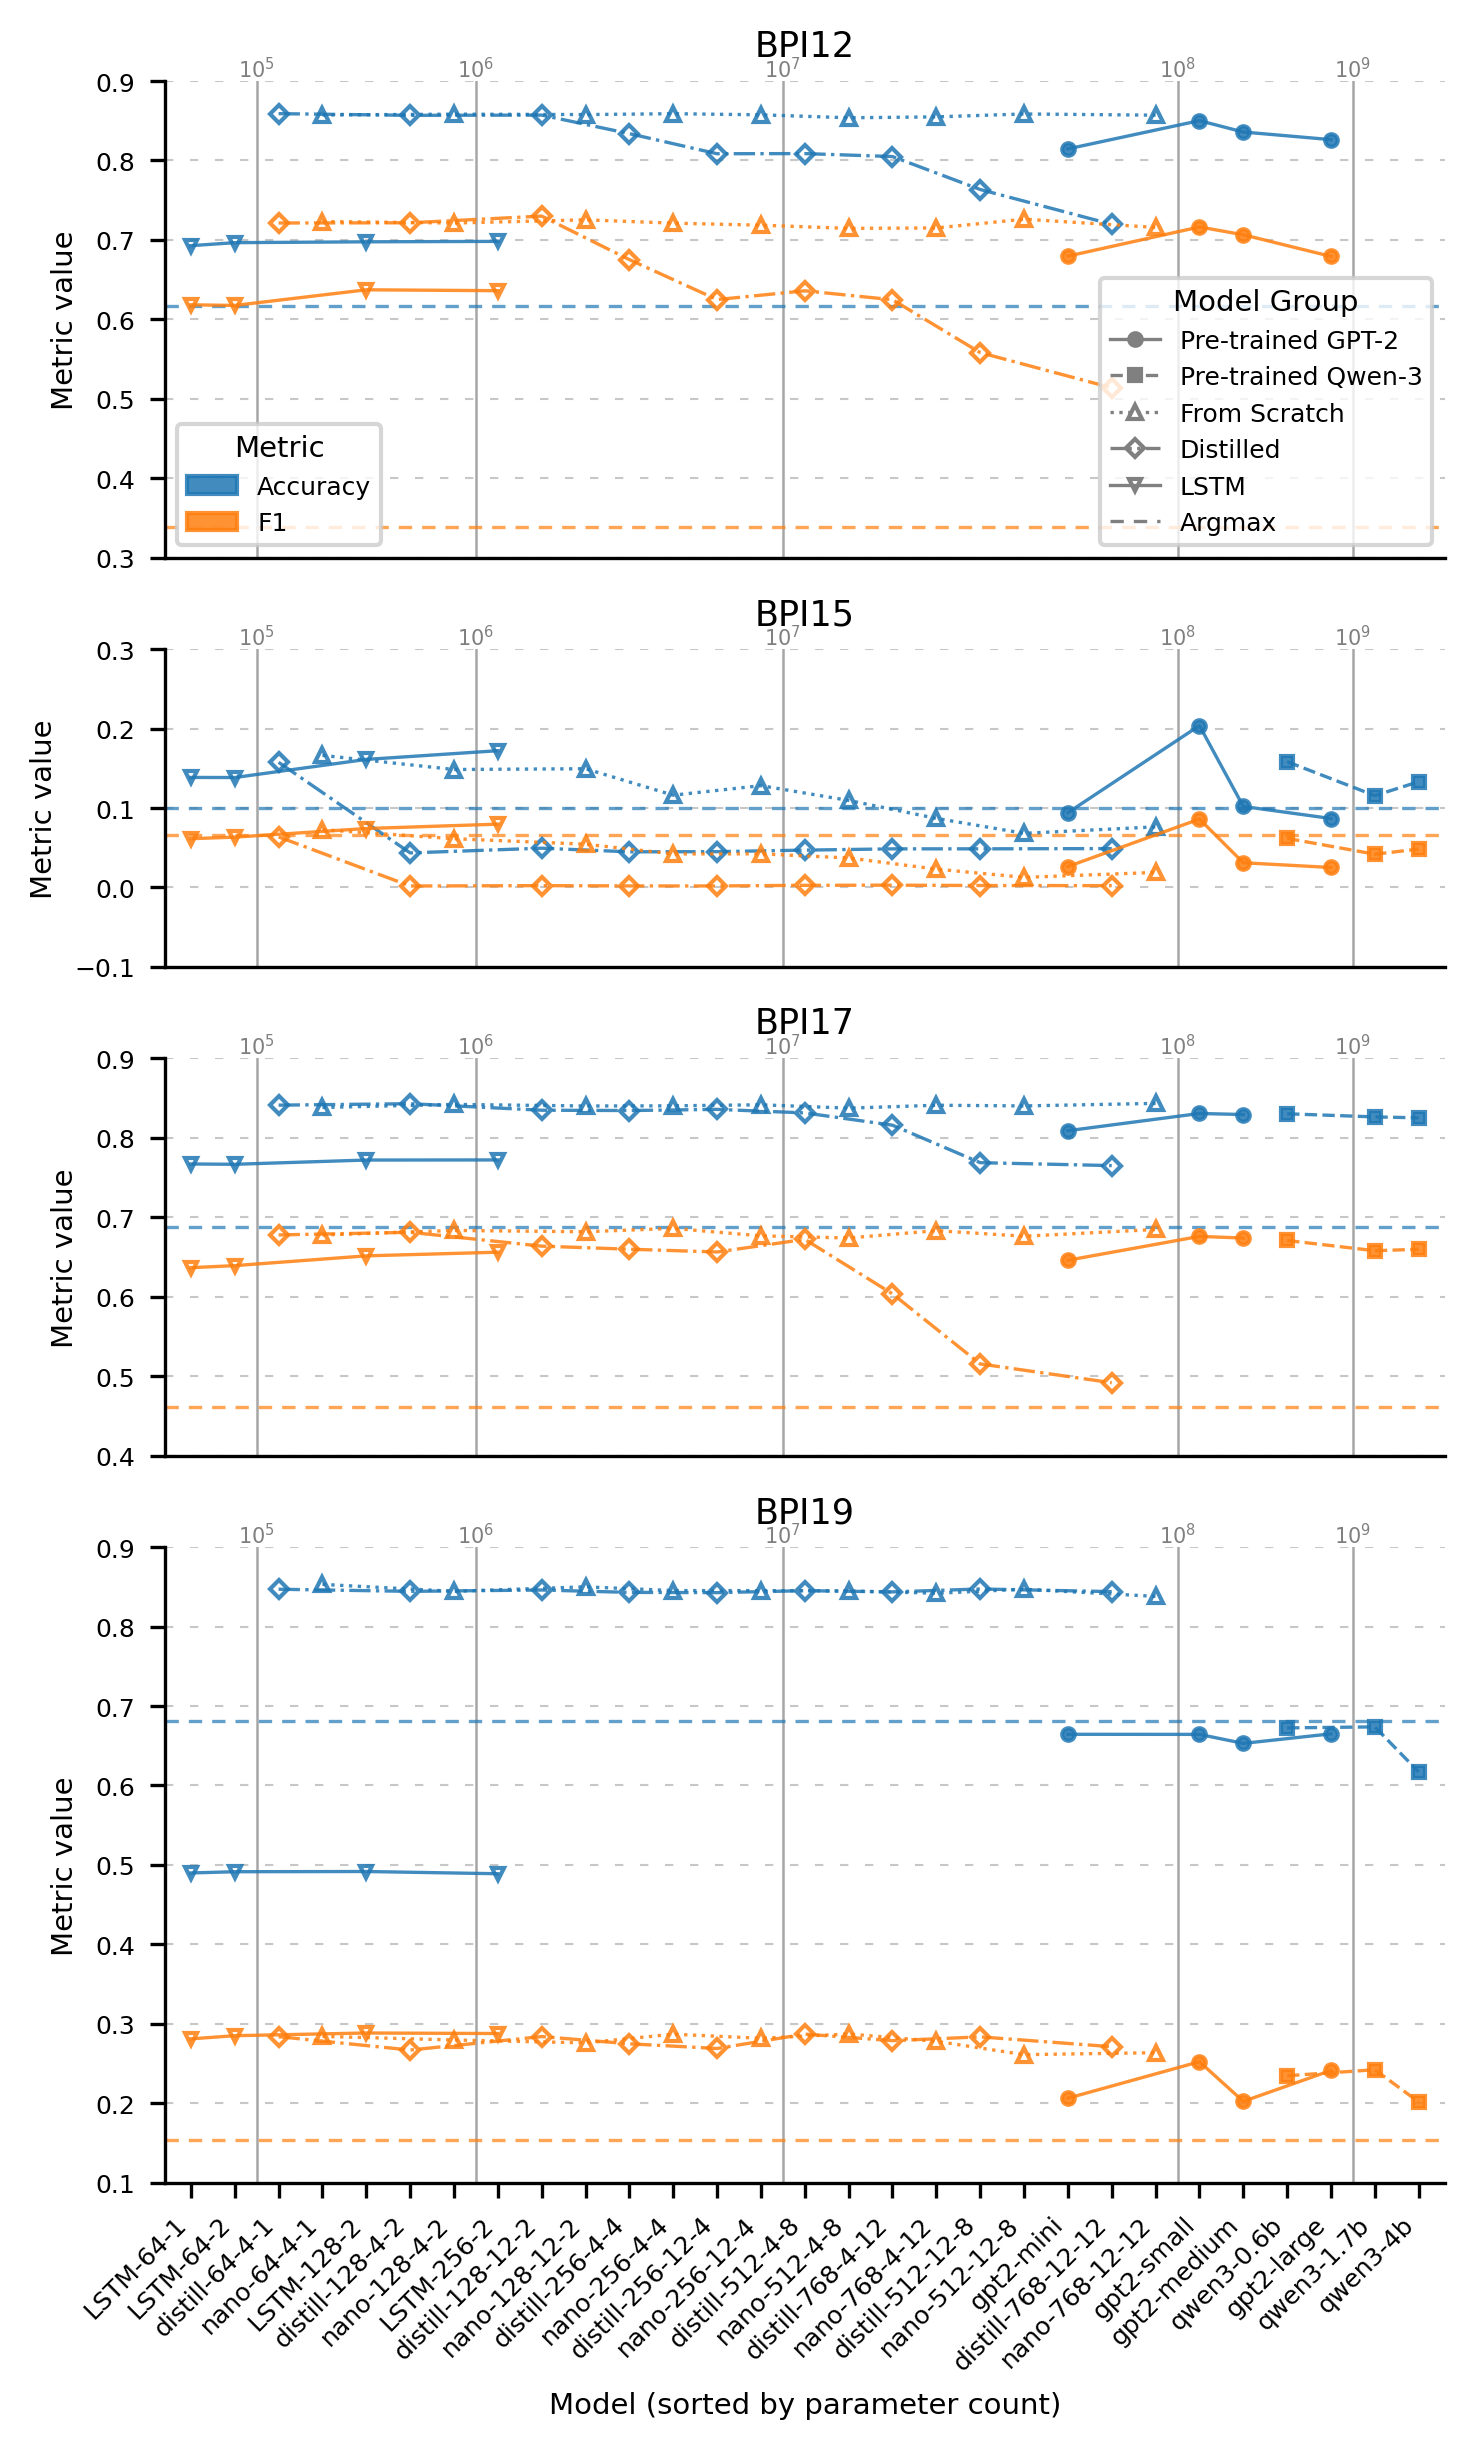

Saved: /app/plots/pre-training/all-models-page2.png


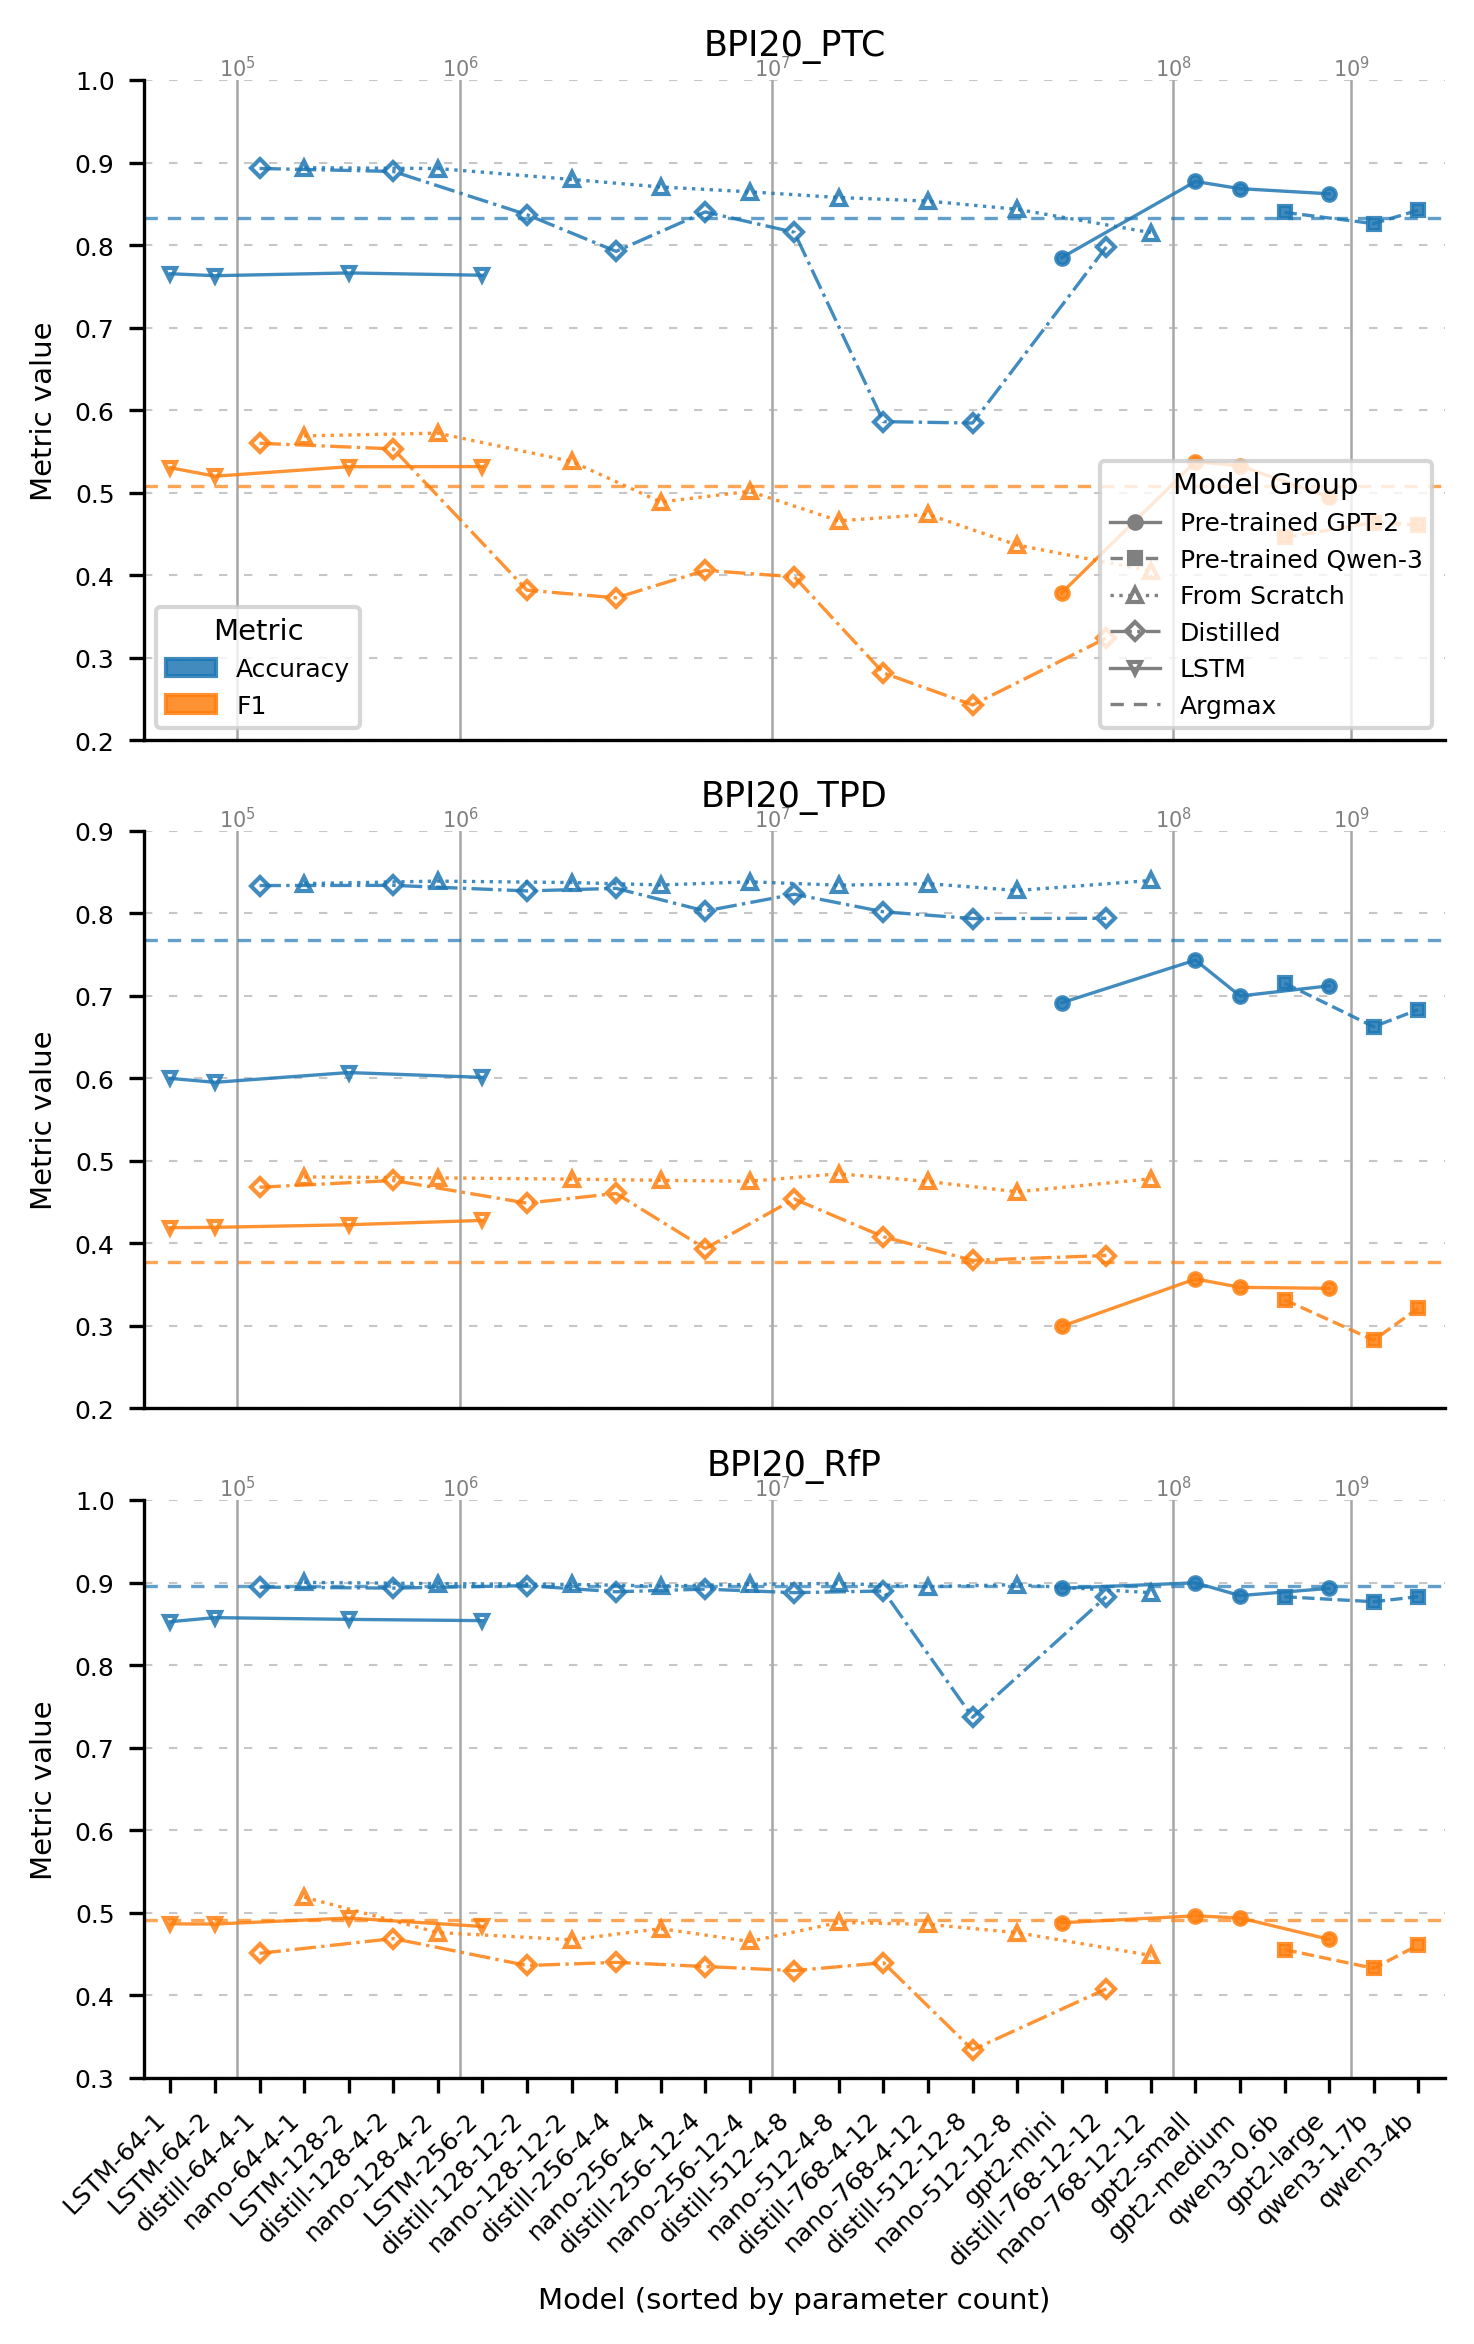

In [74]:
# ── fixed scale constant ──────────────────────────────────────────────────────
INCHES_PER_UNIT = 3.5   # physical inches per 1.0 of y-axis — tune to taste

def compute_ylim(target_log):
    plot_df = build_plot_df(target_log)
    if plot_df.empty:
        return (0.0, 1.0)
    vals = plot_df["mean"].dropna()
    if vals.empty:
        return (0.0, 1.0)
    lo = np.floor((vals.min() - 0.02) * 10) / 10
    hi = min(1.0, np.ceil ((vals.max() + 0.02) * 10) / 10)
    return (lo, hi)


def draw_subplot(ax, target_log, ylim, show_xlabels=False):
    plot_df = build_plot_df(target_log)
    if plot_df.empty:
        ax.text(0.5, 0.5, f"No data for {target_log}",
                ha="center", va="center", transform=ax.transAxes)
        ax.set_title(target_log)
        return

    baseline_df = plot_df[plot_df["backbone"].isin(BASELINE_MODELS)].copy()
    model_df    = plot_df[~plot_df["backbone"].isin(BASELINE_MODELS)].copy()
    model_df["group_idx"] = model_df["backbone"].map(get_group)
    model_df["slot"]      = model_df["backbone"].map(slot_map)

    n_groups = len(MODEL_GROUPS)

    for metric_label in METRICS:
        for gi in range(n_groups):
            sub = model_df[
                (model_df["metric"] == metric_label) &
                (model_df["group_idx"] == gi)
            ].sort_values("slot")
            if sub.empty:
                continue

            x = sub["slot"].values
            y = sub["mean"].values
            marker, ls, fillstyle, ms = GROUP_STYLES[gi]
            color = METRIC_COLORS[metric_label]

            ax.plot(
                x, y,
                marker=marker,
                linestyle=ls,
                color=color,
                fillstyle=fillstyle,
                markersize=ms,
                linewidth=0.8,
                alpha=0.85,
                zorder=3,
            )

    # baselines — horizontal lines only, no labels
    for baseline_name in BASELINE_MODELS:
        for metric_label in METRICS:
            row = baseline_df[
                (baseline_df["backbone"] == baseline_name) &
                (baseline_df["metric"] == metric_label)
            ]
            if row.empty:
                continue
            y_val = row["mean"].values[0]
            color = METRIC_COLORS[metric_label]
            ax.axhline(y_val, color=color, linewidth=0.8,
                       linestyle=(0, (4, 3)), alpha=0.7, zorder=2)

    # decade boundary lines
    params_sorted = label_df["total_params"].values
    slots_sorted  = label_df["slot"].values
    if len(params_sorted) >= 2:
        p_min, p_max = params_sorted[0], params_sorted[-1]
        exp_min = int(np.floor(np.log10(p_min)))
        exp_max = int(np.ceil (np.log10(p_max)))
        for exp in range(exp_min, exp_max + 1):
            threshold = 10 ** exp
            if threshold <= p_min or threshold > p_max:
                continue
            below = slots_sorted[params_sorted < threshold]
            if len(below) == 0:
                continue
            vline_x = below[-1] + 0.5
            ax.axvline(vline_x, color="black", linewidth=0.6,
                       linestyle="-", alpha=0.35, zorder=1)
            label_str = f"10$^{{{exp}}}$" if exp >= 4 else _fmt_params(threshold)
            ax.text(
                vline_x, 1.0, label_str,
                transform=ax.get_xaxis_transform(),
                ha="center", va="bottom",
                fontsize=5, color="black", alpha=0.5,
            )

    ax.set_xlim(-0.6, len(label_df) - 0.4)
    ax.set_ylim(ylim)
    ax.set_ylabel("Metric value")
    ax.set_title(target_log)
    ax.grid(True, axis="y", linestyle=(0, (4, 8)), linewidth=0.5, alpha=0.7)
    ax.spines[["top", "right"]].set_visible(False)

    if show_xlabels:
        ax.set_xticks(label_df["slot"].values)
        ax.set_xticklabels(label_df["slot_key"].values, rotation=45, ha="right")
        ax.set_xlabel("Model (sorted by parameter count)")
    else:
        ax.set_xticks(label_df["slot"].values)
        ax.set_xticklabels([], visible=False)
        ax.tick_params(axis="x", length=0)


# ── page 1 ────────────────────────────────────────────────────────────────────

page1_logs   = TARGET_LOGS[:4]
page1_ylims  = [compute_ylim(tlog) for tlog in page1_logs]
page1_ranges = [hi - lo for lo, hi in page1_ylims]

fig1, axes1 = plt.subplots(
    4, 1,
    figsize=(4.80, INCHES_PER_UNIT * sum(page1_ranges)),
    gridspec_kw={"height_ratios": page1_ranges},
    constrained_layout=True,
)
for i, (ax, tlog, ylim) in enumerate(zip(axes1, page1_logs, page1_ylims)):
    draw_subplot(ax, tlog, ylim=ylim, show_xlabels=(i == len(page1_logs) - 1))

metric_patches, group_handles = make_legend_handles()
legend1_metric = axes1[0].legend(handles=metric_patches, loc="lower left", title="Metric")
axes1[0].add_artist(legend1_metric)
axes1[0].legend(handles=group_handles, loc="lower right", title="Model Group")

fname1 = plots_dir / "all-models-page1.png"
fig1.savefig(fname1, bbox_inches="tight", dpi=300)
print(f"Saved: {fname1}")
plt.show()

# ── page 2 ────────────────────────────────────────────────────────────────────

page2_logs   = TARGET_LOGS[4:]
page2_ylims  = [compute_ylim(tlog) for tlog in page2_logs]
page2_ranges = [hi - lo for lo, hi in page2_ylims]

fig2, axes2 = plt.subplots(
    3, 1,
    figsize=(4.80, INCHES_PER_UNIT * sum(page2_ranges)),
    gridspec_kw={"height_ratios": page2_ranges},
    constrained_layout=True,
)
for i, (ax, tlog, ylim) in enumerate(zip(axes2, page2_logs, page2_ylims)):
    draw_subplot(ax, tlog, ylim=ylim, show_xlabels=(i == len(page2_logs) - 1))

metric_patches, group_handles = make_legend_handles()
legend2_metric = axes2[0].legend(handles=metric_patches, loc="lower left", title="Metric")
axes2[0].add_artist(legend2_metric)
axes2[0].legend(handles=group_handles, loc="lower right", title="Model Group")

fname2 = plots_dir / "all-models-page2.png"
fig2.savefig(fname2, bbox_inches="tight", dpi=300)
print(f"Saved: {fname2}")
plt.show()

In [70]:
runs[runs["backbone"] == "nano_512_4_8"]["total_params"].value_counts()

Series([], Name: count, dtype: int64)

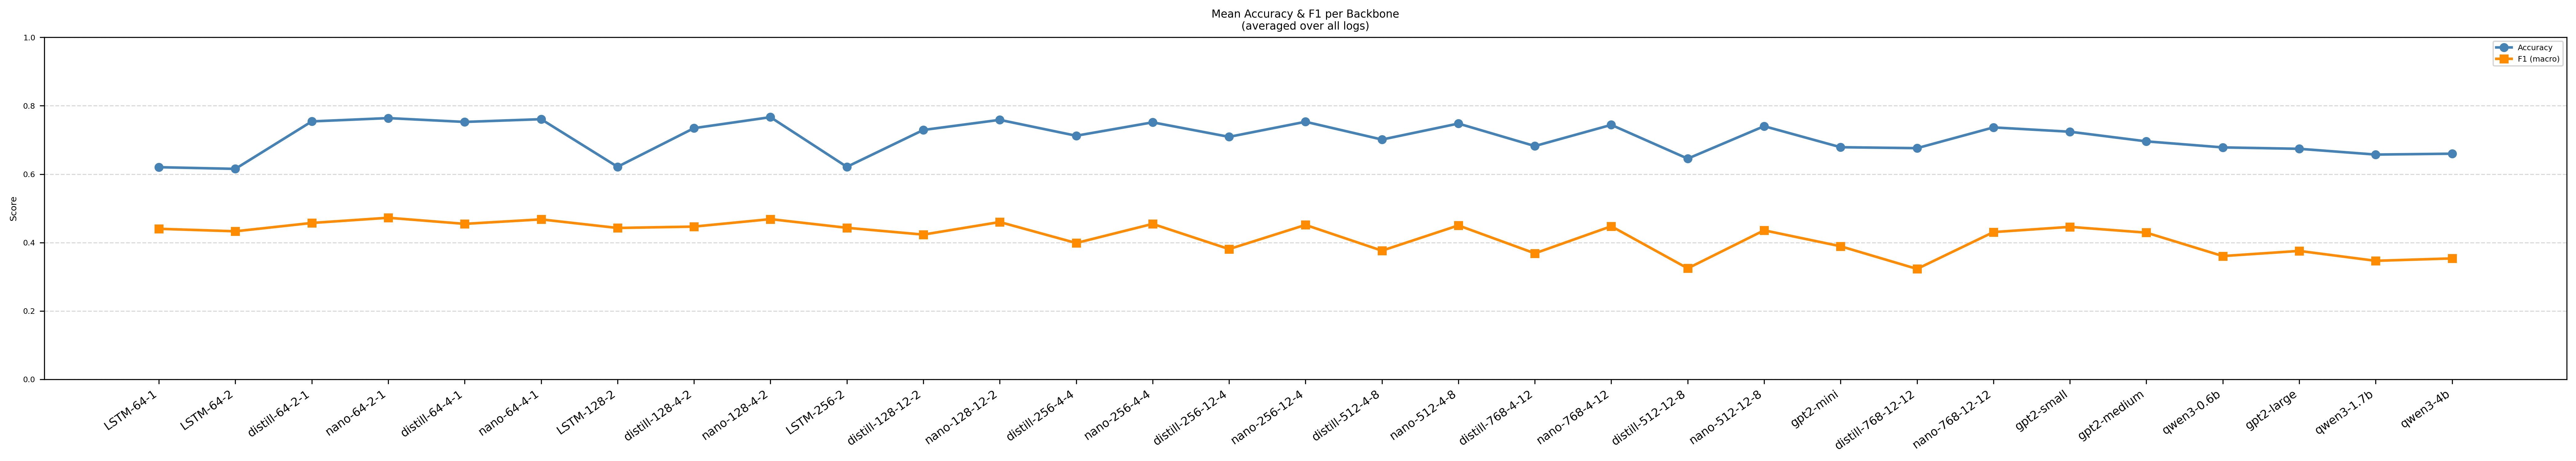

         backbone      acc       f1
        LSTM-64-1 0.620394 0.440299
        LSTM-64-2 0.615532 0.432968
   distill-64-2-1 0.754311 0.457362
      nano-64-2-1 0.763968 0.472545
   distill-64-4-1 0.752802 0.454754
      nano-64-4-1 0.760794 0.467823
       LSTM-128-2 0.621601 0.442703
  distill-128-4-2 0.734588 0.446713
     nano-128-4-2 0.766714 0.468544
       LSTM-256-2 0.621414 0.443203
 distill-128-12-2 0.729222 0.423309
    nano-128-12-2 0.758847 0.460075
  distill-256-4-4 0.712392 0.398675
     nano-256-4-4 0.751618 0.454590
 distill-256-12-4 0.709144 0.380899
    nano-256-12-4 0.753285 0.451638
  distill-512-4-8 0.701251 0.376312
     nano-512-4-8 0.748029 0.450165
 distill-768-4-12 0.682253 0.368520
    nano-768-4-12 0.744173 0.447700
 distill-512-12-8 0.645442 0.324590
    nano-512-12-8 0.740344 0.435860
        gpt2-mini 0.678821 0.389181
distill-768-12-12 0.676069 0.322953
   nano-768-12-12 0.736755 0.430654
       gpt2-small 0.724147 0.445911
      gpt2-medium 0.695962 0

In [71]:
# Cell: Average accuracy and F1 per backbone (across all logs)

import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

METRIC_ACC = "best_test_final_next_activity_acc"
METRIC_F1  = "best_test_final_next_activity_f1"

for col in ["categorical_features", "continuous_features"]:
    if col in runs.columns:
        runs[col] = runs[col].astype(str)

# Drop baseline if present
df2 = runs[runs["project"] != "baseline-nep"].copy()

# Keep only rows with at least one metric
df2 = df2.dropna(subset=[METRIC_ACC, METRIC_F1], how="all").copy()
df2[METRIC_ACC] = pd.to_numeric(df2[METRIC_ACC], errors="coerce")
df2[METRIC_F1]  = pd.to_numeric(df2[METRIC_F1],  errors="coerce")

# Aggregate per backbone (mean over all logs & freeze settings)
agg2 = (
    df2.groupby("backbone")[[METRIC_ACC, METRIC_F1]]
       .mean()
       .rename(columns={METRIC_ACC: "acc", METRIC_F1: "f1"})
       .reset_index()
)

# ── backbone ordering by total_params (if available), else alphabetical ──
if "total_params" in runs.columns:
    param_map = (
        df2.groupby("backbone")["total_params"]
           .median()
           .to_dict()
    )
    agg2["_sort_key"] = agg2["backbone"].map(param_map)
    agg2 = agg2.sort_values("_sort_key").drop(columns="_sort_key")
else:
    agg2 = agg2.sort_values("backbone")

agg2 = agg2.reset_index(drop=True)

backbones = agg2["backbone"].tolist()
n = len(backbones)

# ── equi-spaced x positions (same logic as before) ──
x_pos = np.arange(n)

fig, ax = plt.subplots(figsize=(max(8, n * 0.9), 5))

ax.plot(x_pos, agg2["acc"], marker="o", color="steelblue",  linewidth=2, label="Accuracy")
ax.plot(x_pos, agg2["f1"],  marker="s", color="darkorange", linewidth=2, label="F1 (macro)")

ax.set_xticks(x_pos)
ax.set_xticklabels(backbones, rotation=35, ha="right", fontsize=9)
ax.set_ylabel("Score")
ax.set_title("Mean Accuracy & F1 per Backbone\n(averaged over all logs)")
ax.legend()
ax.grid(axis="y", linestyle="--", alpha=0.5)
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(plots_dir / "backbone_avg_acc_f1.png", dpi=150)
plt.show()
print(agg2.to_string(index=False))